# ch13 · 蒙特卡洛族

## Why this chapter
ch12 共轭先验把一切 shortcutto 给出 closed form; 但现代贝叶斯几乎都涉及非线性或非共轭概率, 不能算 closed form. MC 采样族 (Rejection / Importance / MH / HMC) 让你"任意分布也能采" — 这是工业贝叶斯的核心.

## 学完后能解决
- 写拒绝采样的接纳率公式与 stop criterion
- 写重要性采样的权重自归一, 给你期望估计 std
- 推 MH 接受率 min(1, π(y)q(y,x)/π(x)q(x,y)) 与 Beta target 仿真
- 用 numpyro 一键采 Beta-Binomial 后验, 与 ch12 PyMC 对比


## 2. 直觉: 拒绝采样 (拒绝掉山顶, 留下与目标同形状)

引入建议分布 q(x) 易采样, 富裕目标 π(x). 取 M 使 Mq(x) ≥ π(x) ∀x. 抽 x~q, u~U(0,1); 接纳 x if u ≤ π(x)/(Mq(x)); 否则重试.


接收率: 0.335


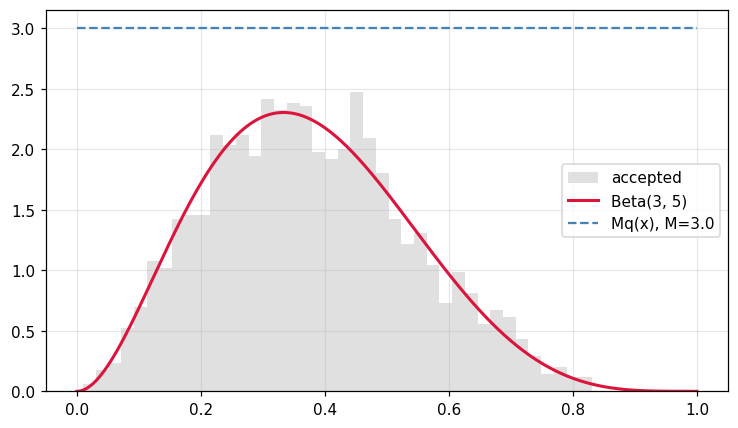

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta
rng = np.random.default_rng(seed=20240717)

# 目标: Beta(3, 5)
def target(x):
    return beta.pdf(x, 3, 5)

# 提议: U(0, 1) + scaling M
M = 3.0
accepted = []; total = 0
for _ in range(5000):
    x = rng.uniform(0, 1)
    u = rng.uniform(0, 1)
    total += 1
    if u <= target(x) / (M * 1.0):  # q=U(0,1), density=1
        accepted.append(x)
accepted = np.array(accepted)
print(f"接收率: {len(accepted)/total:.3f}")
xs = np.linspace(0, 1, 300)
plt.figure(figsize=(8, 4.5), dpi=110)
plt.hist(accepted, bins=40, density=True, color="lightgray", alpha=0.7, label="accepted")
plt.plot(xs, target(xs), color="crimson", lw=2, label="Beta(3, 5)")
plt.plot(xs, M*np.ones_like(xs), ls="--", color="steelblue", label=f"Mq(x), M={M}")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


## 3. 公式

### 接受率
$$P(\text{accept}) = \int \frac{\pi(x)}{M q(x)} q(x) dx = \frac{1}{M} \int \pi(x) dx \approx 1/M$$
(若 π 已归一化等 = 1/M)

### 重要性采样 $
E_\pi[g(X)] = \int g(x) \pi(x) dx = \int g(x) w(x) q(x) dx, \quad w(x) = \pi(x)/q(x)$
采样有 $\hat E = \frac{1}{N}\sum_i g(x_i) w(x_i), x_i \sim q$.

Self-normalized: $\hat E = \sum_i w_i g(x_i) / \sum_i w_i$ (当 π 不可归一).

### Metropolis-Hastings
提议 q(y|x);  接受率 $\alpha = \min\left(1, \frac{\pi(y)q(x|y)}{\pi(x)q(y|x)}\right)$.

### HMC (Hamiltonian)
引入动量 p ~ N(0, M); 沿能量 cliff 跑 leapfrog; 接受率为中心 Hamiltonian 比例; 用梯度信息混合效率高 N 倍.


## 4. 推导: MH 接受率


In [2]:
import numpy as np
# 验证 MH 在 Beta(2, 5) target 上的样本与真值吻合
rng = np.random.default_rng(seed=20240717)

def target(x):
    if x <= 0 or x >= 1: return 0
    return x * (1 - x)**4  # 与 Beta(2, 5) 形状成正比

# Random-walk Gaussian proposal q(y|x) = N(x, 0.2²)
def mh_sampled(N=20000, burn=2000, sigma=0.2, rng_=None):
    if rng_ is None: rng_ = np.random.default_rng(seed=0)
    x = 0.5; samples = []
    for t in range(N + burn):
        y = x + rng_.normal(0, sigma)
        a = min(1, target(y) / target(x))  # q对称时比例简化
        if rng_.uniform() < a:
            x = y
        if t >= burn:
            samples.append(x)
    return np.array(samples)

s = mh_sampled(N=20000)
print(f"sample mean = {s.mean():.4f}")
print(f"true Beta(2,5) mean = {2/(2+5):.4f}")
print(f"sample var = {s.var():.4f}, true var = {(2*5)/(7**2 * 8):.4f}")


sample mean = 0.2888
true Beta(2,5) mean = 0.2857
sample var = 0.0254, true var = 0.0255


## 5. 数值验证: importance sampling std


In [3]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
# 求 E_pi[x] 其中 pi = N(2, 1); q = N(0, 4)
from scipy.stats import norm
N = 10000
x_s = rng.normal(0, 2, N)
weights = norm.pdf(x_s, 2, 1) / norm.pdf(x_s, 0, 2)
# Self-normalized
est = np.sum(weights * x_s) / np.sum(weights)
# Effective sample size
ess = (np.sum(weights)**2) / np.sum(weights**2)
print(f"IS estimate of E_pi[x] = {est:.4f} (true 2.0)")
print(f"ESS = {ess:.1f} of N={N}")
print(f"variance of weights = {weights.var():.4f}")


IS estimate of E_pi[x] = 2.0134 (true 2.0)
ESS = 3737.6 of N=10000
variance of weights = 1.6769


## 6. 可视化: MH 轨迹 vs prior


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


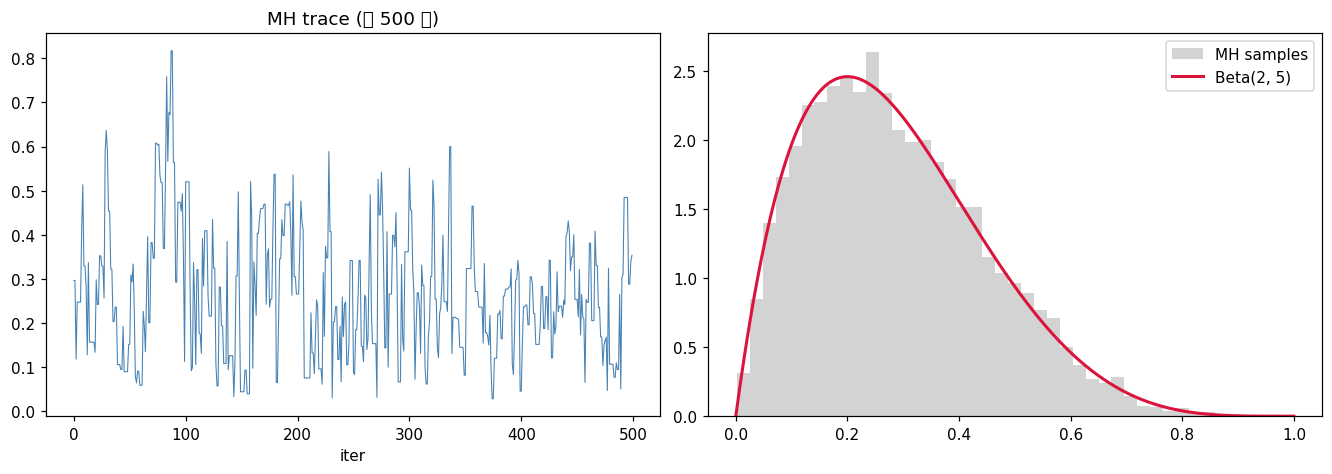

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 续上节用 s
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=110, constrained_layout=True)
axes[0].plot(s[:500], color="steelblue", lw=0.7)
axes[0].set_xlabel("iter"); axes[0].set_title("MH trace (前 500 步)")
axes[1].hist(s, bins=40, density=True, color="lightgray", label="MH samples")
xs = np.linspace(0, 1, 200)
from scipy.stats import beta
axes[1].plot(xs, beta.pdf(xs, 2, 5), color="crimson", lw=2, label="Beta(2, 5)")
axes[1].legend()
plt.show()


## 7. 工程案例: numpyro 抽 Beta-Binomial


In [5]:
# numpyro MCMC 抽后验; 与 ch12 PyMC 对照
try:
    import jax
    import jax.numpy as jnp
    import numpyro
    import numpyro.distributions as dist
    from numpyro.infer import MCMC, NUTS

    numpyro.set_host_device_count(1)

    def model(clicks, impressions):
        p = numpyro.sample("p", dist.Beta(1.0, 1.0))
        numpyro.sample("k", dist.Binomial(total_count=impressions, probs=p), obs=clicks)

    rng_key = jax.random.PRNGKey(20240717)
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=500, num_samples=2000, num_chains=1, progress_bar=False)
    clicks_j = jnp.int32(30); impressions_j = jnp.int32(1000)
    mcmc.run(rng_key, clicks=clicks_j, impressions=impressions_j)
    s_numpyro = mcmc.get_samples()["p"]
    print(f"numpyro posterior p mean = {s_numpyro.mean():.4f}")
    print(f"numpyro sample size = {len(s_numpyro)}")
except Exception as exc:
    print("numpyro err:", exc)
    import numpy as np
    from scipy.stats import beta as beta_d
    print("Fallback analytic: Beta(31, 971)")
    print(f"  mean = {31/(31+971):.4f}")


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


numpyro posterior p mean = 0.0310
numpyro sample size = 2000


## 8. pitfalls
- MH 提议尺度太大无法接收, 太小混时间长: 自适应调 σ (经验 σ = 2.4/√d 在 RW)
- HMC step size 太大会逃逸 (NaN); 用 NUTS 自动选择
- Importance sampling std 爆炸在 weights 大尾巴 → 用 truncation 或 self-normalize
- Burn-in 不能省; 否则前一两百步还依赖初值污染结果
- Diagnose: ESS 太低 → 加 chain 或重新参数化

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| MacKay | Ch.29-30 |
| Murphy | §19.2-19.4 |
| Hoffman & Gelman 2014 | NUTS |

下一章 ch14 (已交付). 然后是 ch15 PGM + RL.
